# 02 — Generate Mesh

This notebook meshes the STEP model with Gmsh, selects fixed/load regions at opposite ends,
and writes a CalculiX-compatible `.inp` file.

## What this notebook does

- Rebuilds the same deterministic geometry.
- Generates a 3D tetra mesh with configurable mesh size.
- Selects node sets by the major axis end faces.
- Writes the CalculiX input deck and a mesh preview image.

In [6]:
import json
import logging
import sys
from dataclasses import asdict, is_dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

def find_module_root(start: Path | None = None) -> Path:
    current = start or Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate the fea_cad_one_sample module root.')

def json_safe(value: Any) -> Any:
    if is_dataclass(value):
        return json_safe(asdict(value))
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    return value

def write_json(path: Path, payload: Any) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(json_safe(payload), indent=2, sort_keys=True) + '\n', encoding='utf-8')
    return path

def load_json(path: Path) -> dict[str, Any]:
    return json.loads(Path(path).read_text(encoding='utf-8'))

MODULE_ROOT = find_module_root()
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

import src.interfaces as iface

plt.style.use('seaborn-v0_8-whitegrid')
print(f'[SETUP] MODULE_ROOT={MODULE_ROOT}')

[SETUP] MODULE_ROOT=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample


In [9]:
RUN_DIR = MODULE_ROOT / 'outputs' / 'sample_00689964' / '01_dataset_original'
SOURCE_STEP_PATH = RUN_DIR / "original.step" 
MESH_SIZE_MM = 10.0
LOAD_MAGNITUDE_N = 200.0

In [11]:

print('[STAGE] mesh: prepare geometry and mesh STEP')
config = iface.build_baseline_config(
    run_dir=RUN_DIR,
    source_step_path=SOURCE_STEP_PATH,
    mesh_size_mm=MESH_SIZE_MM,
    load_magnitude_n=LOAD_MAGNITUDE_N,
)

INFO src.fea_replication.pipeline: build_baseline_config | start | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original | source_step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step | mesh_size_mm=10.0 | load_magnitude_n=200.0
INFO src.fea_replication.pipeline: build_baseline_config | done | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original


[STAGE] mesh: prepare geometry and mesh STEP


In [12]:

geometry = iface.prepare_geometry_artifacts(config, force=True)
mesh = iface.generate_calculix_mesh(config, geometry, force=True)


INFO src.fea_replication.geometry: prepare_geometry_artifacts | start | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original | source_step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step | force=True
INFO src.fea_replication.geometry: render_geometry_preview | start | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/cantilever_beam.step | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/geometry_preview.png | force=True
INFO src.fea_replication.geometry: render_geometry_preview | done | ou

Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 1' (3D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 70%] Meshing curve 14 (Circle)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 80%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Line)
Info    : [ 90%] Meshing curve 18 (Line)
Info    : [ 90%] Meshing curve 19 (Line)
Info    : [100%] Meshing curve 20 (Line)
Info    : [100%] Meshing curve 21 (Circle)
Info    : Done meshing 1D (Wall 0.000482833s, CPU 0.

  mesh.inp_path = /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/analysis.inp
  mesh.preview_path = /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/mesh_preview.png
  mesh.summary_path = /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/mesh_summary.json
  node_count = 36
  element_count = 74
  element_type_counts = {'C3D4': 74}
  fixed_region = fixed end face near min axis
  load_region = free end face near maximum axis
  major_axis = Y
  fixed_node_count = 36
  load_node_count = 36
  lower_threshold_mm = 14.785714
  upper_threshold_mm = -14.24975


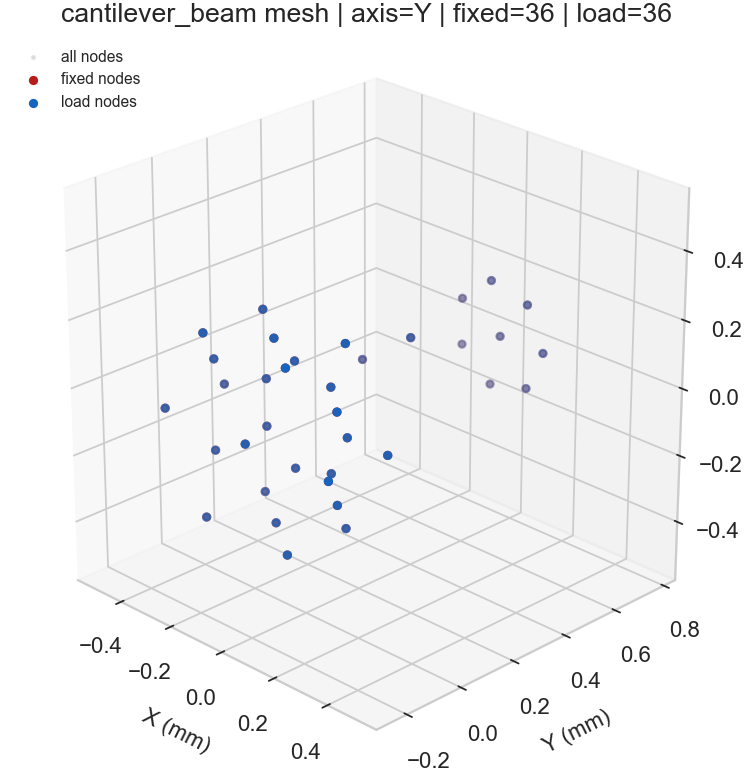

✓ mesh ready


In [13]:

print('  mesh.inp_path =', mesh.inp_path)
print('  mesh.preview_path =', mesh.preview_path)
print('  mesh.summary_path =', mesh.summary_path)
print('  node_count =', mesh.node_count)
print('  element_count =', mesh.element_count)
print('  element_type_counts =', mesh.element_type_counts)
print('  fixed_region =', config.boundary_condition.fixed_region)
print('  load_region =', config.load.target_region)
print('  major_axis =', mesh.region_selection.major_axis)
print('  fixed_node_count =', len(mesh.region_selection.fixed_node_ids))
print('  load_node_count =', len(mesh.region_selection.load_node_ids))
print('  lower_threshold_mm =', mesh.region_selection.lower_threshold_mm)
print('  upper_threshold_mm =', mesh.region_selection.upper_threshold_mm)
display(Image(filename=str(mesh.preview_path)))
print('✓ mesh ready')